# Heart Disease Prediction Using Machine Learning

### A Machine Learning Classification Project for Predicting the Presence of Heart Disease

## Project Overview

Heart disease is one of the major health-related challenges worldwide. 
Early identification of individuals who may be at higher risk can support 
timely medical attention and further clinical evaluation.

In this project, machine learning techniques are used to analyze clinical 
and demographic patient information and predict whether a patient is likely 
to have heart disease.

The project follows an end-to-end machine learning workflow, including data 
understanding, exploratory data analysis, data preprocessing, model 
development, model evaluation, model comparison, and selection of a final 
model for deployment.

The final selected machine learning model will be integrated into an 
interactive application to demonstrate real-time predictions.

> **Disclaimer:** This project is intended for educational and predictive 
> modeling purposes only. It is not a medical diagnostic system and should 
> not be used as a substitute for professional medical advice or diagnosis.

## Project Objectives

The main objectives of this project are:

1. Understand and explore the heart disease dataset.
2. Identify data quality issues such as missing values and inconsistent entries.
3. Perform exploratory data analysis to understand relationships between features.
4. Prepare categorical and numerical features for machine learning.
5. Split the dataset into training and testing sets using an appropriate methodology.
6. Apply suitable preprocessing techniques such as encoding and feature scaling.
7. Train and evaluate multiple classification algorithms.
8. Compare the performance of the trained models using appropriate evaluation metrics.
9. Select the most suitable model based on its overall predictive performance.
10. Save the final model and required preprocessing components for deployment.
11. Develop an interactive application that allows users to obtain model predictions.

## Problem Definition

### Problem Type

This project is a **supervised machine learning classification problem**.

The objective is to predict whether a patient has heart disease based on 
the available clinical and demographic features.

### Target Variable

The target variable is:

**`HeartDisease`**

where:

- `1` represents the presence of heart disease.
- `0` represents the absence of heart disease.

### Input Features

The model uses patient characteristics and clinical measurements such as:

- Age
- Sex
- Chest Pain Type
- Resting Blood Pressure
- Cholesterol
- Fasting Blood Sugar
- Resting Electrocardiogram results
- Maximum Heart Rate
- Exercise-Induced Angina
- Oldpeak
- ST Slope

The task can therefore be represented as:

**Patient Features → Machine Learning Model → Heart Disease Prediction**

## Dataset Description

The dataset contains patient-level clinical and demographic information 
along with a binary target variable indicating the presence or absence of 
heart disease.

Each row represents an individual patient, while each column represents 
a patient characteristic or clinical measurement.

The dataset contains both:

- **Numerical features**, such as Age, RestingBP, Cholesterol, MaxHR, and Oldpeak.
- **Categorical features**, such as Sex, ChestPainType, RestingECG, ExerciseAngina, and ST_Slope.

The target variable, `HeartDisease`, is binary and is used for supervised 
classification.

## 1. Importing Required Libraries

The following libraries are used for data manipulation, numerical 
computations, visualization, and machine learning.

Only libraries required for the analysis are imported to keep the 
notebook organized and maintainable.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Loading the Dataset

The heart disease dataset is loaded from a CSV file using Pandas.

After loading the dataset, its structure and contents will be examined 
before performing any preprocessing or modeling.

In [2]:
df = pd.read_csv("../data/heart.csv")

## 1. Dataset Inspection

The dataset is inspected for structure, data types, statistical properties,
missing values, duplicates, and unique values to identify data-quality
issues before further analysis.

### 1.1 Dataset Preview

The first and last few observations are examined to verify that the dataset
has been loaded correctly and to understand the structure of individual
records.

In [3]:
display(df.head())
display(df.tail())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


### 1.2 Dataset Dimensions

The dimensions of the dataset are examined to determine the number of
observations and features available for analysis.

In [4]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Number of observations: 918
Number of features: 12


### 1.3 Dataset Structure and Data Types

`info()` is used to check each feature's data type and non-null count,
since numerical and categorical features require different preprocessing.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


### 1.4 Statistical Summary

`describe()` is used to check the central tendency, spread, and range of
the numerical features.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


### 1.5 Feature Names

The column names are displayed to identify the available variables in the
dataset and distinguish predictor variables from the target variable.

In [7]:
df.columns.tolist()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

### 1.6 Missing Value Assessment

Missing values are checked across all features, since most ML algorithms
can't handle them directly.

In [8]:
missing_values = df.isnull().sum()

print("Missing values by column:")
display(missing_values.to_frame("Missing Values"))

Missing values by column:


,Missing Values
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [9]:
missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Values,Missing Percentage
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


### 1.7 Duplicate Record Assessment

Duplicate records are checked, since repeated observations can bias model
training if left unhandled.

In [10]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### 1.8 Feature Cardinality

Unique value counts per feature are checked to identify categorical
variables and which ones will need encoding before model training.

In [11]:
feature_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

display(feature_summary)

,Data Type,Unique Values,Missing Values
Age,int64,50,0
Sex,str,2,0
ChestPainType,str,4,0
RestingBP,int64,67,0
Cholesterol,int64,222,0
FastingBS,int64,2,0
RestingECG,str,3,0
MaxHR,int64,119,0
ExerciseAngina,str,2,0
Oldpeak,float64,53,0


In [12]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * 50)
    print(df[column].value_counts(dropna=False))


Sex
--------------------------------------------------
Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
--------------------------------------------------
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
--------------------------------------------------
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
--------------------------------------------------
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
--------------------------------------------------
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_11508\785520118.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


## 2. Target Variable Analysis

`HeartDisease` is the outcome variable. Its class distribution is checked
to see whether the dataset is balanced or has notable class imbalance.

In [13]:
target_counts = df["HeartDisease"].value_counts()

display(target_counts.to_frame("Count"))

,Count
HeartDisease,
1,508
0,410


### 2.1 Target Class Distribution

The proportion of each target class is calculated to provide a clearer view
of the class distribution.

In [14]:
target_percentage = (
    df["HeartDisease"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(target_percentage.to_frame("Percentage"))

,Percentage
HeartDisease,
1,55.34
0,44.66


### 2.2 Visualization of Target Distribution

A count plot visualizes the number of observations in each HeartDisease
class for a quick check of the target distribution.

C:\Users\DELL\AppData\Local\Temp\ipykernel_11508\4070254197.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Heart Disease (0)", "Heart Disease (1)"])


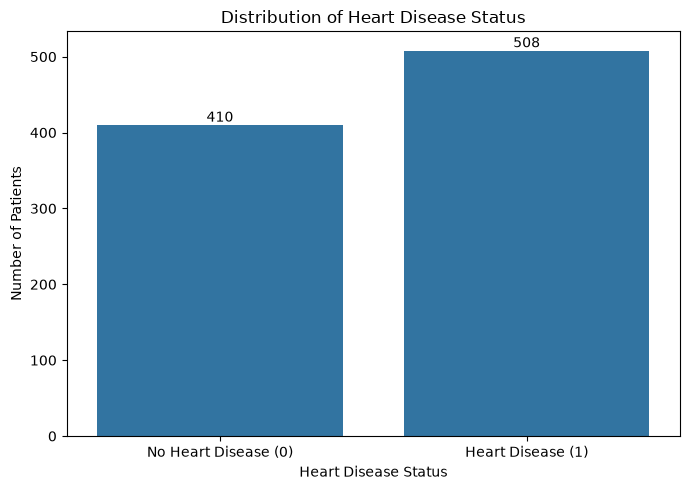

In [15]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="HeartDisease"
)

plt.title("Distribution of Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

ax.set_xticklabels(["No Heart Disease (0)", "Heart Disease (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 2.3 Insight: Target Class Distribution

Of 918 records, 508 (55.34%) are `HeartDisease` = 1 and 410 (44.66%) are
`HeartDisease` = 0 — a moderate, not extreme, imbalance. Both classes are
usable for training, with stratified sampling considered during the
train-test split to preserve this distribution.

### 3.1 Distribution of Numerical Features

Histograms with KDE visualize the distribution of Age, RestingBP,
Cholesterol, and MaxHR to check their range, shape, and skewness before
preprocessing.

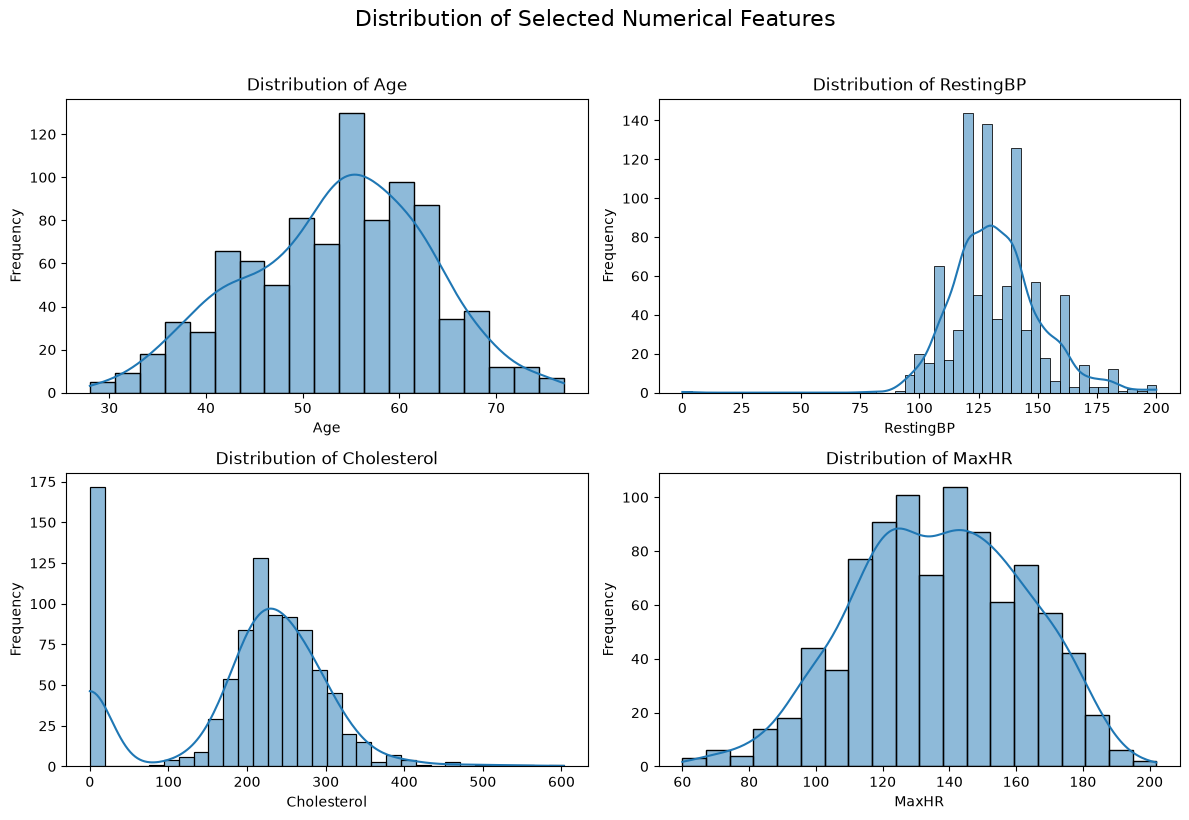

In [16]:
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

for ax, feature in zip(axes.flat, numerical_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax
    )
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

fig.suptitle(
    "Distribution of Selected Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### 3.4 Key Insights

- **Age:** Relatively smooth distribution, concentrated in the middle-age range.
- **RestingBP:** Mostly 100–150 mmHg; one zero value needs investigation.
- **Cholesterol:** Prominent spike at zero (172 records, 18.74%) — potentially invalid or unrecorded, needs investigation.
- **MaxHR:** Relatively smooth, concentrated in the middle of the range.

Cholesterol shows the most notable data-quality concern and will be
investigated before preprocessing.

### 3.3 Assessment of Potentially Invalid Values

Some numerical features may contain zero values that require further
investigation. Zero values are identified before making any changes to the
dataset.

In [17]:
zero_counts = (df[numerical_features] == 0).sum()

display(
    zero_counts.to_frame("Zero Values")
)

,Zero Values
Age,0
RestingBP,1
Cholesterol,172
MaxHR,0


### Investigation of Potentially Invalid Values

The zero-value analysis identified 172 records with `Cholesterol = 0` and
one record with `RestingBP = 0`.

The record with `RestingBP = 0` also contains `Cholesterol = 0` and
`FastingBS = 0`. These observations require further investigation before
any data-cleaning or imputation strategy is applied.

In [18]:
cholesterol_zero = df[df["Cholesterol"] == 0]

print(f"Records with Cholesterol = 0: {len(cholesterol_zero)}")

display(cholesterol_zero.head())

Records with Cholesterol = 0: 172


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1


In [19]:
restingbp_zero = df[df["RestingBP"] == 0]

print(f"Records with RestingBP = 0: {len(restingbp_zero)}")

display(restingbp_zero)

Records with RestingBP = 0: 1


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


### 3.6 Quantifying Potentially Invalid Values

The proportion of zero values in the affected features is calculated to
assess whether they represent a minor issue or a substantial portion of
the dataset.

In [20]:
zero_summary = pd.DataFrame({
    "Zero Count": (df[["RestingBP", "Cholesterol"]] == 0).sum(),
    "Zero Percentage": (
        (df[["RestingBP", "Cholesterol"]] == 0).mean() * 100
    ).round(2)
})

display(zero_summary)

,Zero Count,Zero Percentage
RestingBP,1,0.11
Cholesterol,172,18.74


### 3.7 Investigation of Zero-Value Features

`RestingBP` and `Cholesterol` zero values are treated as likely missing
measurements. Since Cholesterol has 18.74% zeros, we retain the observations
and examine non-zero distributions to guide the imputation strategy instead
of dropping data.

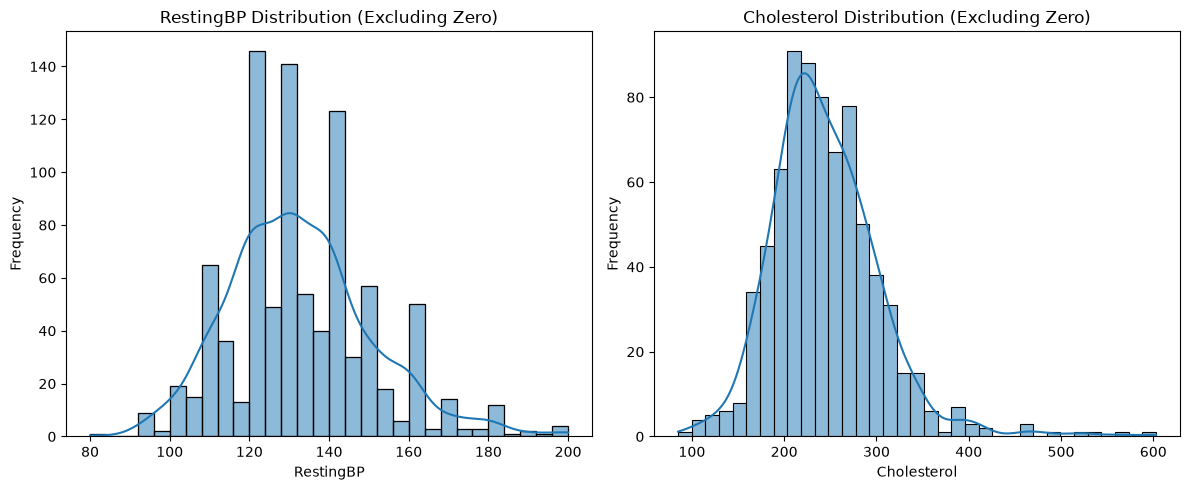

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    df.loc[df["RestingBP"] > 0, "RestingBP"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("RestingBP Distribution (Excluding Zero)")
axes[0].set_xlabel("RestingBP")
axes[0].set_ylabel("Frequency")

sns.histplot(
    df.loc[df["Cholesterol"] > 0, "Cholesterol"],
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Cholesterol Distribution (Excluding Zero)")
axes[1].set_xlabel("Cholesterol")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Insight:**

`RestingBP` is roughly symmetric (after its 1 zero value), while
`Cholesterol` is right-skewed with 18.74% zero values — likely missing
measurements, not true readings. Median imputation fits Cholesterol better
due to skew. Actual imputation for both will be done inside the pipeline
(train data only) to avoid data leakage.

In [22]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

# Missing-value indicator for Cholesterol (missingness itself is informative)
df["Cholesterol_Missing"] = df["Cholesterol"].isna().astype(int)

# Confirm conversion
display(df[["RestingBP", "Cholesterol"]].isna().sum().to_frame("Missing Count"))

,Missing Count
RestingBP,1
Cholesterol,172


**Insight:**

RestingBP and Cholesterol zero values are now correctly
encoded as missing (1 and 172 records respectively). Actual imputation is
deferred to the modeling pipeline, fitted only on training data, to avoid
data leakage.

### 3.9 Oldpeak Distribution

`Oldpeak` represents ST-segment depression during exercise relative to
rest. Its distribution is examined for range, concentration, and skewness.

In [23]:
print(df["Oldpeak"].describe())
print(f"\nNegative Oldpeak values: {(df['Oldpeak'] < 0).sum()}")

count    918.000000
mean       0.887364
std        1.066570
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

Negative Oldpeak values: 13


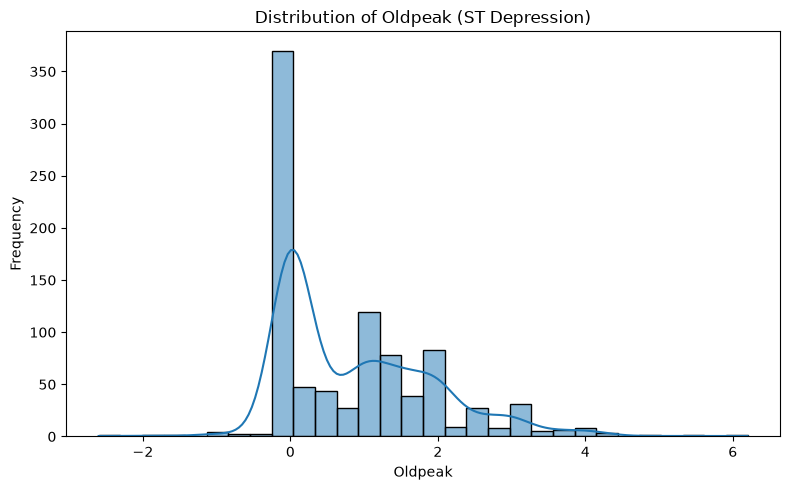

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Oldpeak",
    kde=True,
    bins=30
)

plt.title("Distribution of Oldpeak (ST Depression)")
plt.xlabel("Oldpeak")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Insight:**

Oldpeak is right-skewed with ~40% of values at 0 and a tail
extending to ~6.2. A small number of negative values are kept as-is (not
errors). Given the skew and scale sensitivity, Oldpeak will be standardized
before use in KNN, SVM, and Logistic Regression.

### 4.1 Sex and Heart Disease Distribution

Sex is compared against HeartDisease using a grouped count plot to see how
the target distribution differs between males and females.

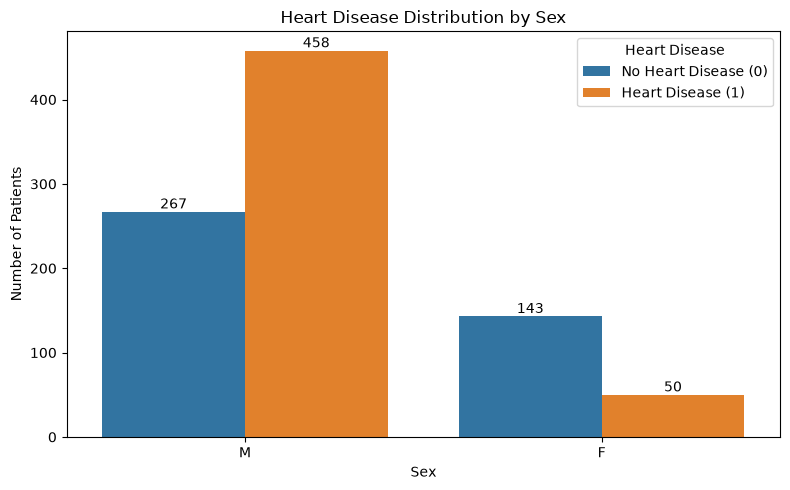

In [25]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Sex",
    hue="HeartDisease"
)

ax.set_title("Heart Disease Distribution by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Number of Patients")

plt.legend(
    title="Heart Disease",
    labels=["No Heart Disease (0)", "Heart Disease (1)"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


### 4.2 Heart Disease Rate by Sex

Male and female group sizes differ (725 vs 193), so we compare normalized
rates instead of raw counts.

HeartDisease      0      1
Sex                       
F             74.09  25.91
M             36.83  63.17


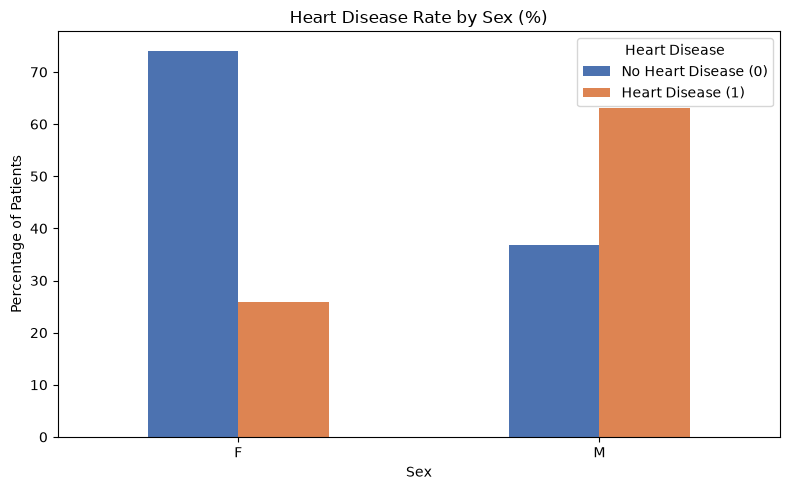

In [26]:
rate_by_sex = pd.crosstab(df["Sex"], df["HeartDisease"], normalize="index").mul(100).round(2)
print(rate_by_sex)

ax = rate_by_sex.plot(kind="bar", stacked=False, figsize=(8, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Heart Disease Rate by Sex (%)")
ax.set_xlabel("Sex")
ax.set_ylabel("Percentage of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])
plt.tight_layout()
plt.show()

**Insight:**

Males have a substantially higher disease rate (63.17%) than
females (25.91%) — Sex looks like a useful predictor. Association only,
not a causal/clinical claim.

### 4.3 Heart Disease Rate by Chest Pain Type

ChestPainType has unequal group sizes (ASY = 54% of data), so we compare
normalized rates, not raw counts.

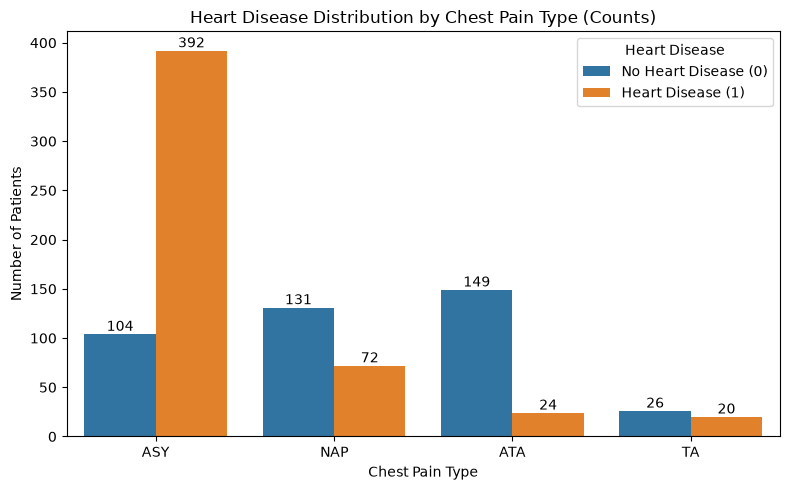

In [27]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="ChestPainType",
    hue="HeartDisease",
    order=df["ChestPainType"].value_counts().index
)

ax.set_title("Heart Disease Distribution by Chest Pain Type (Counts)")
ax.set_xlabel("Chest Pain Type")
ax.set_ylabel("Number of Patients")

plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

HeartDisease       0      1
ChestPainType              
ASY            20.97  79.03
TA             56.52  43.48
NAP            64.53  35.47
ATA            86.13  13.87


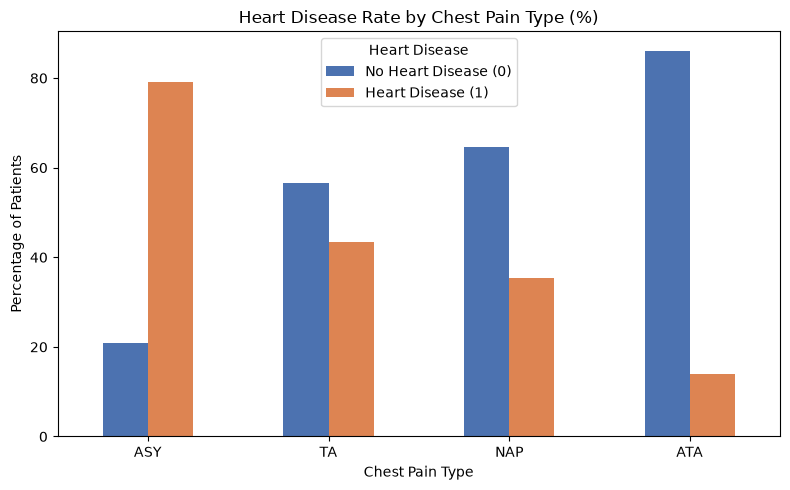

In [28]:
rate_by_cp = pd.crosstab(df["ChestPainType"], df["HeartDisease"], normalize="index").mul(100).round(2)
rate_by_cp = rate_by_cp.sort_values(by=1, ascending=False)
print(rate_by_cp)

ax = rate_by_cp.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Heart Disease Rate by Chest Pain Type (%)")
ax.set_xlabel("Chest Pain Type")
ax.set_ylabel("Percentage of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])
plt.tight_layout()
plt.show()

**Insight:**

ASY (asymptomatic) patients have the highest disease rate (79%),
nearly 6x higher than ATA (14%) — ChestPainType looks like a strong predictor.
Association only, not a causal/clinical claim.

### 4.5 Heart Disease Rate by Resting ECG

`RestingECG` group sizes differ (Normal 60%, LVH 20%, ST 19%), so we compare
normalized rates, not raw counts.

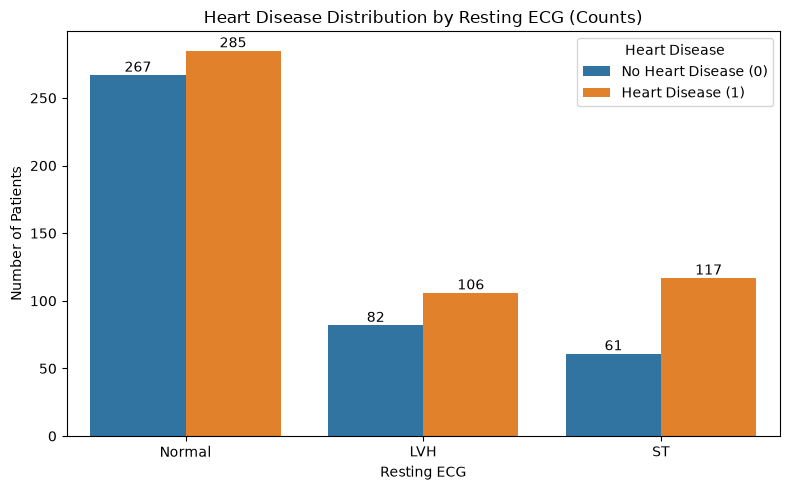

In [29]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="RestingECG",
    hue="HeartDisease",
    order=df["RestingECG"].value_counts().index
)

ax.set_title("Heart Disease Distribution by Resting ECG (Counts)")
ax.set_xlabel("Resting ECG")
ax.set_ylabel("Number of Patients")

plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

HeartDisease      0      1
RestingECG                
ST            34.27  65.73
LVH           43.62  56.38
Normal        48.37  51.63


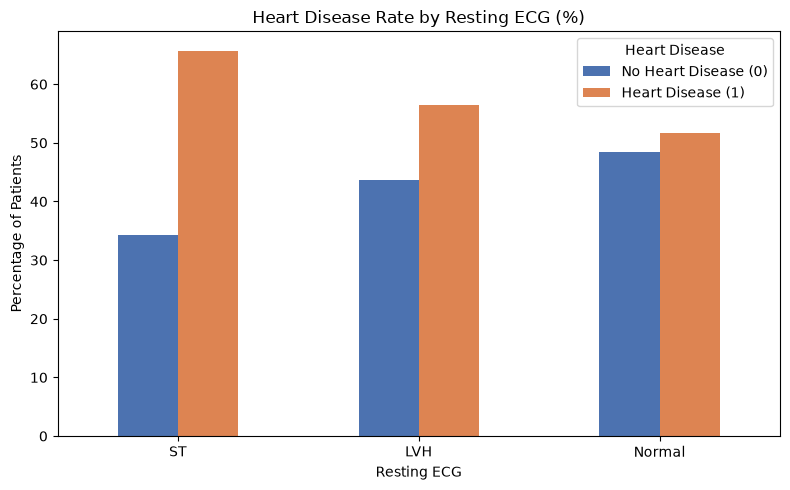

In [30]:
rate_by_ecg = pd.crosstab(df["RestingECG"], df["HeartDisease"], normalize="index").mul(100).round(2)
rate_by_ecg = rate_by_ecg.sort_values(by=1, ascending=False)
print(rate_by_ecg)

ax = rate_by_ecg.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Heart Disease Rate by Resting ECG (%)")
ax.set_xlabel("Resting ECG")
ax.set_ylabel("Percentage of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])
plt.tight_layout()
plt.show()

**Insight:**

`RestingECG` shows a weaker relationship with HeartDisease than
Sex or ChestPainType — rates range from 51.63% (Normal) to 65.73% (ST), a
much smaller spread. Association only, not a causal/clinical claim.

### 4.7 Heart Disease Rate by Exercise Angina

`ExerciseAngina` group sizes differ (N 59.6%, Y 40.4%), so we compare
normalized rates, not raw counts.

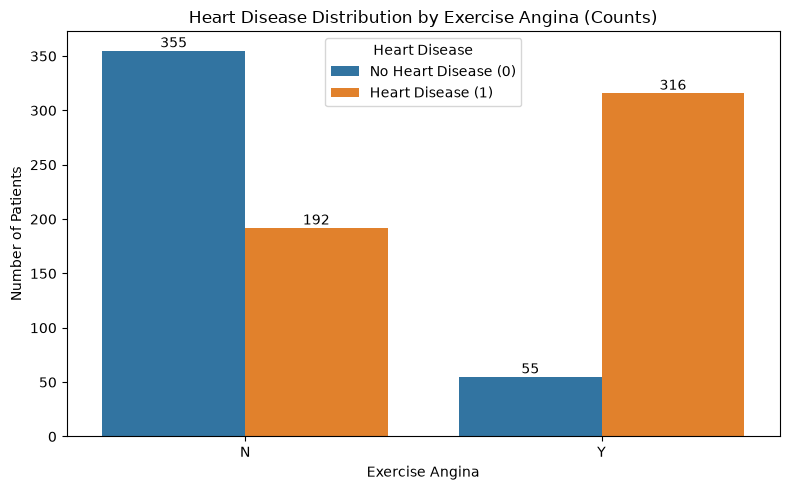

In [31]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="ExerciseAngina",
    hue="HeartDisease",
    order=df["ExerciseAngina"].value_counts().index
)

ax.set_title("Heart Disease Distribution by Exercise Angina (Counts)")
ax.set_xlabel("Exercise Angina")
ax.set_ylabel("Number of Patients")

plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

HeartDisease        0      1
ExerciseAngina              
Y               14.82  85.18
N               64.90  35.10


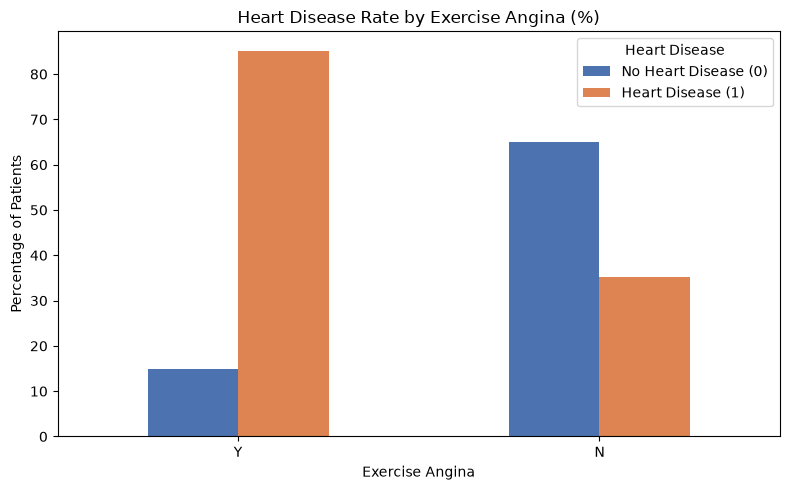

In [32]:
rate_by_angina = pd.crosstab(df["ExerciseAngina"], df["HeartDisease"], normalize="index").mul(100).round(2)
rate_by_angina = rate_by_angina.sort_values(by=1, ascending=False)
print(rate_by_angina)

ax = rate_by_angina.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Heart Disease Rate by Exercise Angina (%)")
ax.set_xlabel("Exercise Angina")
ax.set_ylabel("Percentage of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])
plt.tight_layout()
plt.show()

**Insight:**

Patients with exercise-induced angina have a much higher
disease rate (85.18%) than those without (35.10%) — a 50-point gap, the
strongest categorical signal so far. Association only, not a
causal/clinical claim.

### 4.9 Heart Disease Rate by ST Slope

ST_Slope group sizes differ (Flat 50%, Up 43%, Down 7%), so we compare
normalized rates, not raw counts.

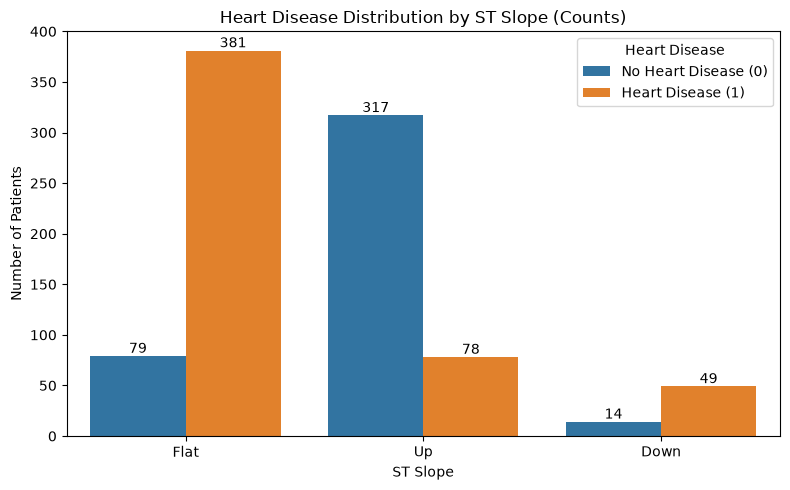

In [33]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="ST_Slope",
    hue="HeartDisease",
    order=df["ST_Slope"].value_counts().index
)

ax.set_title("Heart Disease Distribution by ST Slope (Counts)")
ax.set_xlabel("ST Slope")
ax.set_ylabel("Number of Patients")

plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

HeartDisease      0      1
ST_Slope                  
Flat          17.17  82.83
Down          22.22  77.78
Up            80.25  19.75


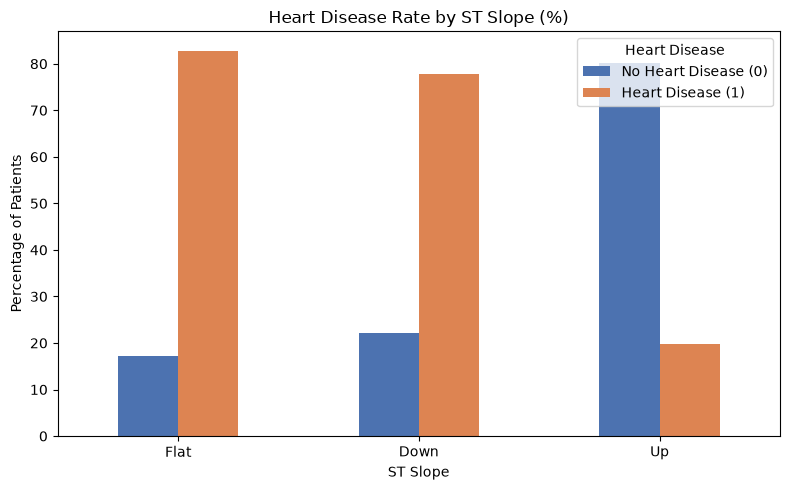

In [34]:
rate_by_slope = pd.crosstab(df["ST_Slope"], df["HeartDisease"], normalize="index").mul(100).round(2)
rate_by_slope = rate_by_slope.sort_values(by=1, ascending=False)
print(rate_by_slope)

ax = rate_by_slope.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Heart Disease Rate by ST Slope (%)")
ax.set_xlabel("ST Slope")
ax.set_ylabel("Percentage of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])
plt.tight_layout()
plt.show()

**Insight:**

ST_Slope shows the strongest categorical signal so far — Up
slope patients have a low disease rate (19.75%) while Flat slope patients
have a high rate (82.83%), a 63-point gap covering 93% of the dataset.
Association only, not a causal/clinical claim.

### 4.10 Heart Disease Rate by Fasting Blood Sugar

FastingBS group sizes differ (0: 76.7%, 1: 23.3%), so we compare
normalized rates, not raw counts.

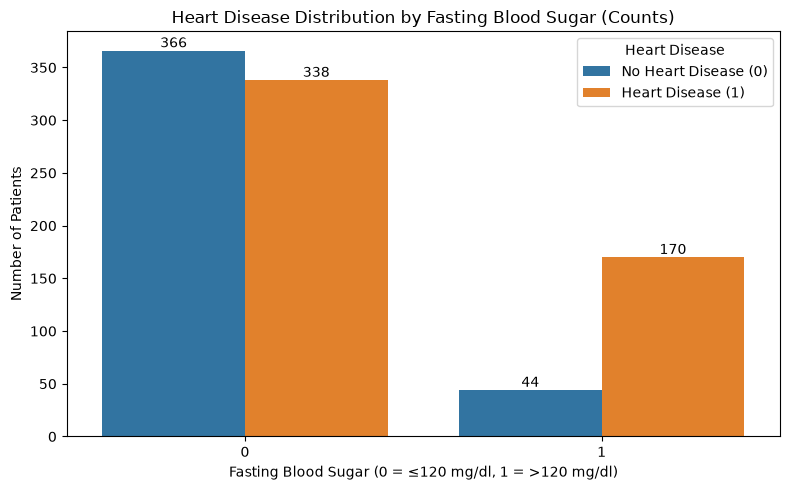

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="FastingBS",
    hue="HeartDisease"
)

ax.set_title("Heart Disease Distribution by Fasting Blood Sugar (Counts)")
ax.set_xlabel("Fasting Blood Sugar (0 = ≤120 mg/dl, 1 = >120 mg/dl)")
ax.set_ylabel("Number of Patients")

plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

HeartDisease      0      1
FastingBS                 
1             20.56  79.44
0             51.99  48.01


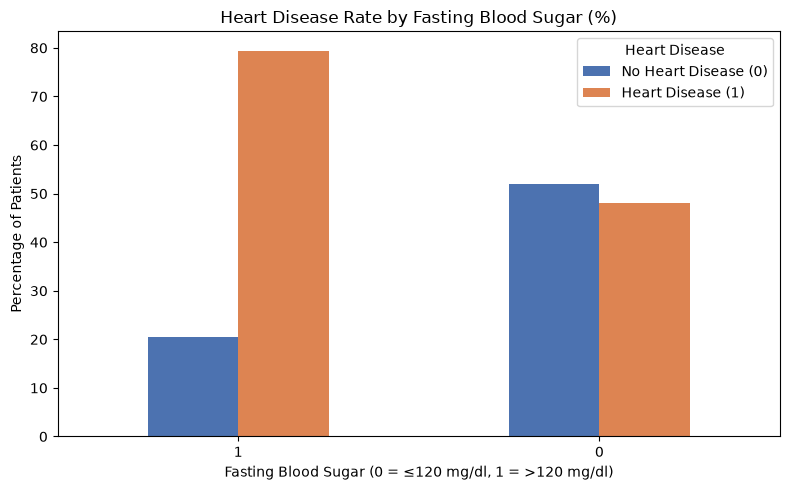

In [36]:
rate_by_fbs = pd.crosstab(df["FastingBS"], df["HeartDisease"], normalize="index").mul(100).round(2)
rate_by_fbs = rate_by_fbs.sort_values(by=1, ascending=False)
print(rate_by_fbs)

ax = rate_by_fbs.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Heart Disease Rate by Fasting Blood Sugar (%)")
ax.set_xlabel("Fasting Blood Sugar (0 = ≤120 mg/dl, 1 = >120 mg/dl)")
ax.set_ylabel("Percentage of Patients")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease", labels=["No Heart Disease (0)", "Heart Disease (1)"])
plt.tight_layout()
plt.show()

**Insight:**

Patients with elevated fasting blood sugar (FastingBS=1) have
a notably higher disease rate (79.44%) than those with normal levels
(48.01%) — a 31-point gap. Association only, not a causal/clinical claim.

### 6.1 Cholesterol Distribution by Heart Disease

Cholesterol=0 records (identified as missing/invalid earlier) are excluded
here to avoid distorting the comparison between disease groups.

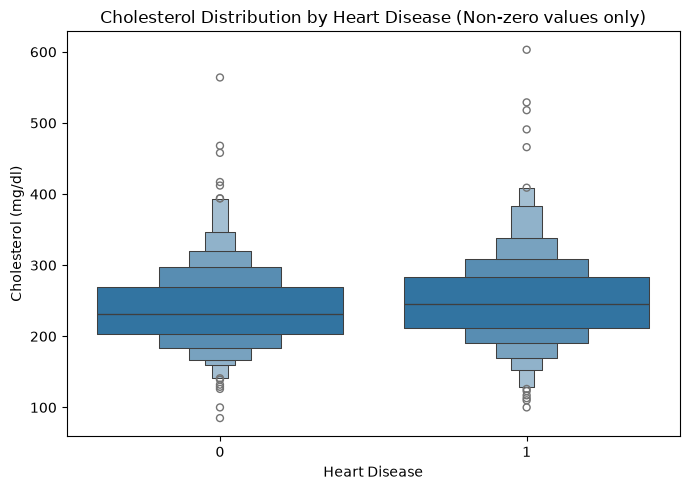

In [37]:
plt.figure(figsize=(7, 5))

sns.boxenplot(
    x="HeartDisease",
    y="Cholesterol",
    data=df[df["Cholesterol"] > 0]  
)

plt.title("Cholesterol Distribution by Heart Disease (Non-zero values only)")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol (mg/dl)")
plt.tight_layout()
plt.show()

**Insight:**

Excluding zero values, patients with heart disease show a
higher median Cholesterol (246) than those without (231.5) — the expected
direction. Including the zero values reverses this pattern, confirming
they must be excluded/imputed properly before analysis.

### 6.2 Age Distribution by Heart Disease

A violin plot compares the Age distribution between patients with and
without heart disease.

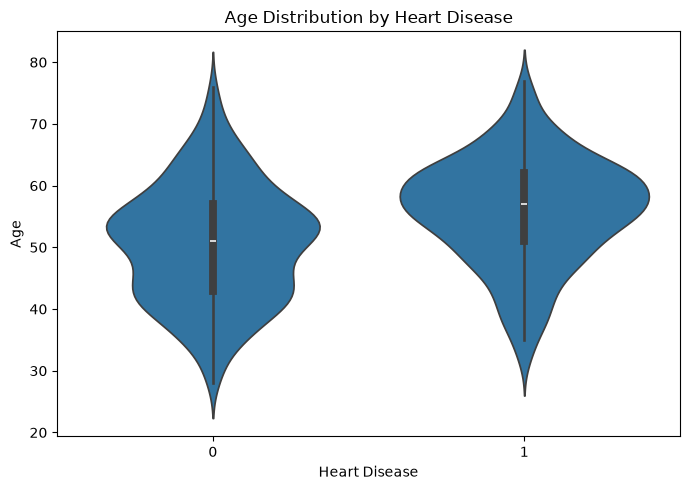

In [38]:
plt.figure(figsize=(7, 5))

sns.violinplot(
    x="HeartDisease",
    y="Age",
    data=df
)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

**Insight:**

Patients with heart disease are older on average (median age
57 vs 51, ~6-year gap), though the distributions overlap substantially —
Age is a moderate, not strong, standalone signal.

### 6.3 RestingBP, MaxHR, and Oldpeak by Heart Disease

Violin/boxen plots compare the distribution of RestingBP, MaxHR, and
Oldpeak between patients with and without heart disease. RestingBP=0 is
excluded as previously identified missing data.

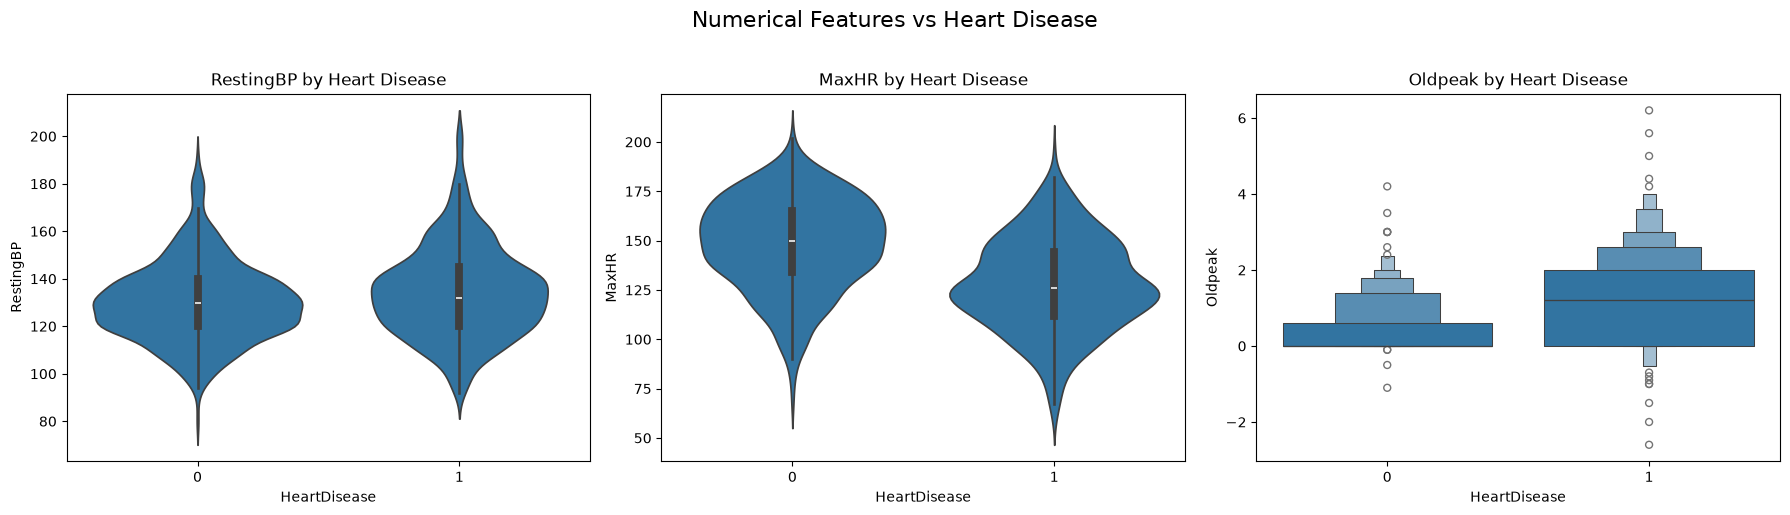

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(x="HeartDisease", y="RestingBP", data=df[df["RestingBP"] > 0], ax=axes[0])
axes[0].set_title("RestingBP by Heart Disease")

sns.violinplot(x="HeartDisease", y="MaxHR", data=df, ax=axes[1])
axes[1].set_title("MaxHR by Heart Disease")

sns.boxenplot(x="HeartDisease", y="Oldpeak", data=df, ax=axes[2])
axes[2].set_title("Oldpeak by Heart Disease")

fig.suptitle("Numerical Features vs Heart Disease", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Insight:**

RestingBP shows only a minor difference between groups (~4
mmHg). MaxHR and Oldpeak show much stronger separation — disease patients
have lower MaxHR (127.66 vs 148.15) and higher Oldpeak (1.27 vs 0.41,
~3x), making both likely strong numerical predictors.

### 7. Correlation Heatmap

Correlations between numerical features and the target are examined.
Cholesterol=0 (missing) values are excluded to avoid a distorted result.

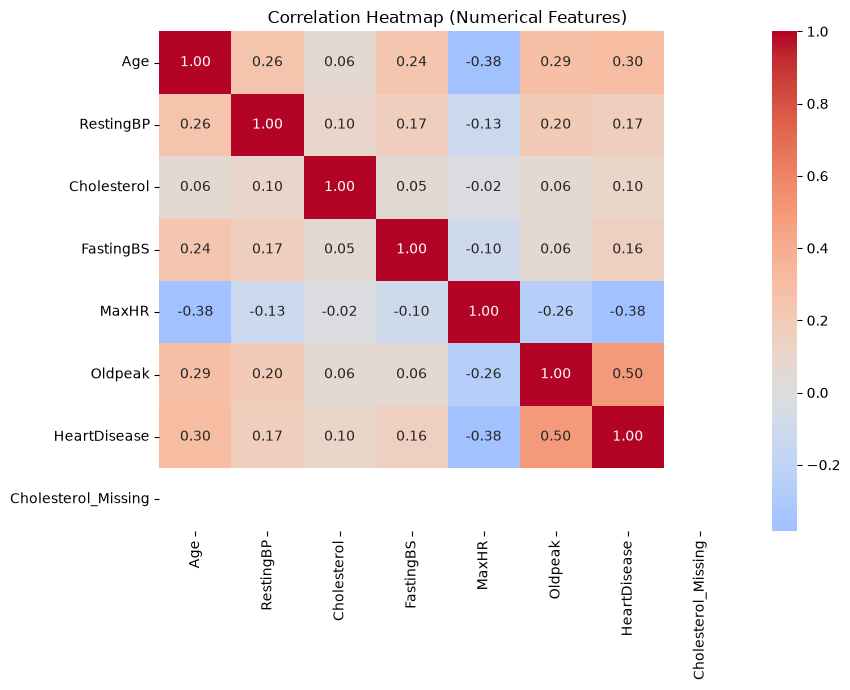

In [40]:
plt.figure(figsize=(9, 7))

corr_matrix = df[df["Cholesterol"] > 0].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

**Insight:**

Oldpeak (+0.40) and MaxHR (-0.40) show the strongest linear
relationship with HeartDisease among numerical features. No pair of
features shows strong multicollinearity, so no features need to be
dropped for redundancy.

## 8. Feature-Target Association (Statistical Tests)

Before building the preprocessing pipeline, the association between each
categorical feature and the target is tested using the Chi-square test of
independence, and each numerical feature's linear relationship with the
target is examined using point-biserial correlation.

In [41]:
from scipy.stats import chi2_contingency

categorical_cols = [
    "Sex", "ChestPainType", "RestingECG",
    "ExerciseAngina", "ST_Slope", "FastingBS"
]

alpha = 0.05
chi2_result = {}

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df["HeartDisease"])
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

    decision = "Reject Null (Keep feature)" if p_val < alpha else "Fail to Reject Null (Consider Dropping)"

    chi2_result[col] = {
        "Chi2_Statistic": round(chi2_stat, 3),
        "p_value": round(p_val, 5),
        "Decision": decision
    }

chi2_df = pd.DataFrame(chi2_result).T.sort_values(by="p_value")
chi2_df

,Chi2_Statistic,p_value,Decision
Sex,84.145,0.0,Reject Null (Keep feature)
ChestPainType,268.067,0.0,Reject Null (Keep feature)
ExerciseAngina,222.259,0.0,Reject Null (Keep feature)
ST_Slope,355.918,0.0,Reject Null (Keep feature)
FastingBS,64.321,0.0,Reject Null (Keep feature)
RestingECG,10.931,0.00423,Reject Null (Keep feature)


In [42]:
from scipy.stats import pointbiserialr

numerical_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

numerical_corr = {}
for col in numerical_cols:
    valid = df[[col, "HeartDisease"]].dropna()
    corr, p_val = pointbiserialr(valid["HeartDisease"], valid[col])
    numerical_corr[col] = {"Correlation": round(corr, 3), "p_value": round(p_val, 5)}

numerical_corr_df = pd.DataFrame(numerical_corr).T.sort_values(by="Correlation", ascending=False)
numerical_corr_df

,Correlation,p_value
Oldpeak,0.404,0.00000
Age,0.282,0.00000
RestingBP,0.118,0.00034
Cholesterol,0.104,0.00451
MaxHR,-0.400,0.00000


**Insight:**

All categorical features show statistically significant
association with HeartDisease (p < 0.05), so none are dropped on
statistical grounds — ST_Slope is the strongest (Chi2 = 355.9), RestingECG
the weakest (Chi2 = 10.9). Among numerical features, Oldpeak and MaxHR show
the strongest linear relationship (|r| ≈ 0.40), while RestingBP and
Cholesterol are weaker but still significant. Notably, Cholesterol's
correlation is now positive (0.104) after correcting the zero-value
encoding, consistent with clinical expectation. No feature is excluded
before modeling.

## 9. Train-Test Split

The dataset is split into training and testing sets before any
preprocessing is fitted, to prevent data leakage. Stratified sampling
preserves the target class distribution in both sets.

In [43]:
from sklearn.model_selection import train_test_split

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (734, 12), Test shape: (184, 12)


## 10. Preprocessing Pipeline

A `ColumnTransformer` is used to apply different preprocessing to numerical
and categorical features. Numerical features are median-imputed (robust to
skew, as seen with Cholesterol and Oldpeak) and scaled. Categorical features
are one-hot encoded with `handle_unknown="ignore"`, so the pipeline works
safely even if deployment input has unseen category combinations. All
preprocessing is fitted only on training data.

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_features = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
passthrough_features = ["Cholesterol_Missing"]

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features),
    ("pass", "passthrough", passthrough_features)
])

## 11. Model Comparison

Each model is wrapped with the same preprocessing pipeline and evaluated
on the held-out test set, ensuring identical, leakage-free preprocessing
across all models.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (RBF Kernel)": SVC(probability=True)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
results_df

c:\Users\DELL\anaconda3\envs\statistic\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,F1 Score
0,Logistic Regression,0.8913,0.9038
4,SVM (RBF Kernel),0.8859,0.8995
2,Naive Bayes,0.8859,0.8986
1,KNN,0.8804,0.8900
3,Decision Tree,0.7554,0.7716


### 11.1 Visual Comparison of Models

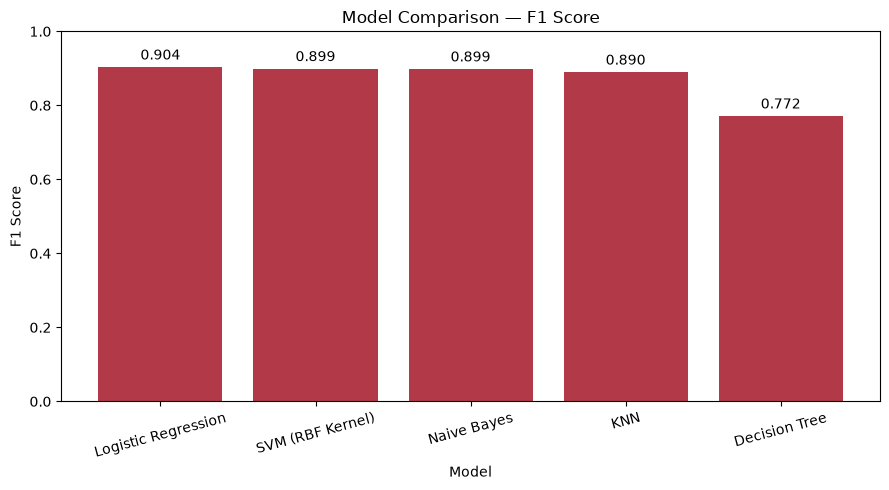

In [46]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["F1 Score"], color="#B23A48")
plt.title("Model Comparison — F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
for i, v in enumerate(results_df["F1 Score"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

## 11.2 Detailed Evaluation of the Best Model

The best-performing model (by F1 score) is examined in more detail using
a confusion matrix, classification report, and ROC curve to understand
its error types and overall discriminative ability.

Best Model: Logistic Regression

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        82
           1       0.89      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



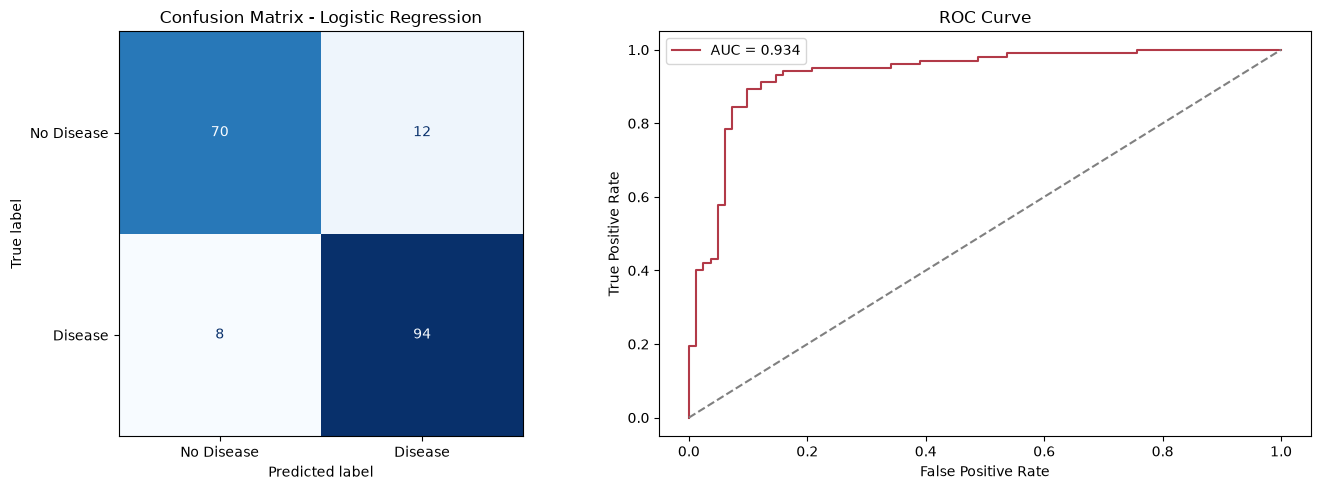

In [47]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, ConfusionMatrixDisplay

best_model_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print(f"Best Model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix - {best_model_name}")

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_score = roc_auc_score(y_test, y_proba_best)
axes[1].plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color="#B23A48")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight:**

Logistic Regression achieves 89% accuracy with balanced
precision/recall across both classes. The AUC of 0.934 indicates strong
discriminative ability between disease and no-disease cases.

Of the 20 misclassifications, 8 are false negatives (predicted healthy but
actually diseased) and 12 are false positives. In a medical screening
context, false negatives are generally more concerning than false
positives, since a missed diagnosis delays treatment while a false alarm
simply prompts further testing. The model's recall for the Disease class
(0.92) is higher than for No Disease (0.85), meaning it is comparatively
better at catching actual disease cases than at avoiding false alarms —
a reasonable trade-off for a screening-oriented tool, though not a
substitute for clinical diagnosis.

In [48]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_pipe, X, y, cv=5, scoring="f1")
print(f"5-Fold CV F1 Scores: {cv_scores.round(3)}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold CV F1 Scores: [0.857 0.866 0.867 0.854 0.768]
Mean CV F1: 0.8426 (+/- 0.0374)


## 12. Saving the Final Pipeline

The complete pipeline (preprocessing + model) is saved as a single object,
eliminating the need for separate scaler and columns files during
deployment.

In [49]:
import joblib

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]

print(f"Best model: {best_model_name}")

joblib.dump(best_pipeline, "../models/heart_disease_pipeline.pkl")

Best model: Logistic Regression


['../models/heart_disease_pipeline.pkl']

## Summary

- Dataset: 918 patient records, 11 clinical features
- Best Model: Logistic Regression (89% accuracy, 0.934 AUC)
- Key predictors: ST_Slope, ChestPainType, ExerciseAngina, Oldpeak, MaxHR
- Final pipeline saved as a single deployable object (`heart_disease_pipeline.pkl`)
- Deployed via Streamlit for interactive risk prediction